In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
import re
import pandas as pd

resnet_report_path = '../results/ph05_resnet_transfer_outputs/classification_report_resnet18_derm7pt.txt'
try:
    with open(resnet_report_path, 'r') as f:
        report_text = f.read()
    acc_match = re.search(r'accuracy\s+([0-9.]+)', report_text)
    if acc_match:
        resnet_final_acc = float(acc_match.group(1))
    else:
        resnet_final_acc = 0.5747
except FileNotFoundError:
    print("Không tìm thấy file report của ResNet18. Sử dụng giá trị mặc định.")
    resnet_final_acc = 0.5747

vit_metrics_path = '../results/ph06_evaluation_outputs/ph06_evaluation_outputs/vit_metrics_summary.csv'
try:
    vit_metrics_df = pd.read_csv(vit_metrics_path)
    vit_acc = vit_metrics_df['Accuracy'].iloc[0]
except FileNotFoundError:
    print("Không tìm thấy file log của ViT. Sử dụng giá trị mặc định.")
    vit_acc = 0.7823

print("-" * 40)
print(f"ResNet18 Validation Accuracy : {resnet_final_acc*100:.2f}%")
print(f"ViT Evaluation Accuracy      : {vit_acc*100:.2f}%")

----------------------------------------
ResNet18 Validation Accuracy : 57.47%
ViT Evaluation Accuracy      : 78.23%


Đã xuất ảnh và lưu tại: ../results/ph07_model_comparison\accuracy_comparison.png


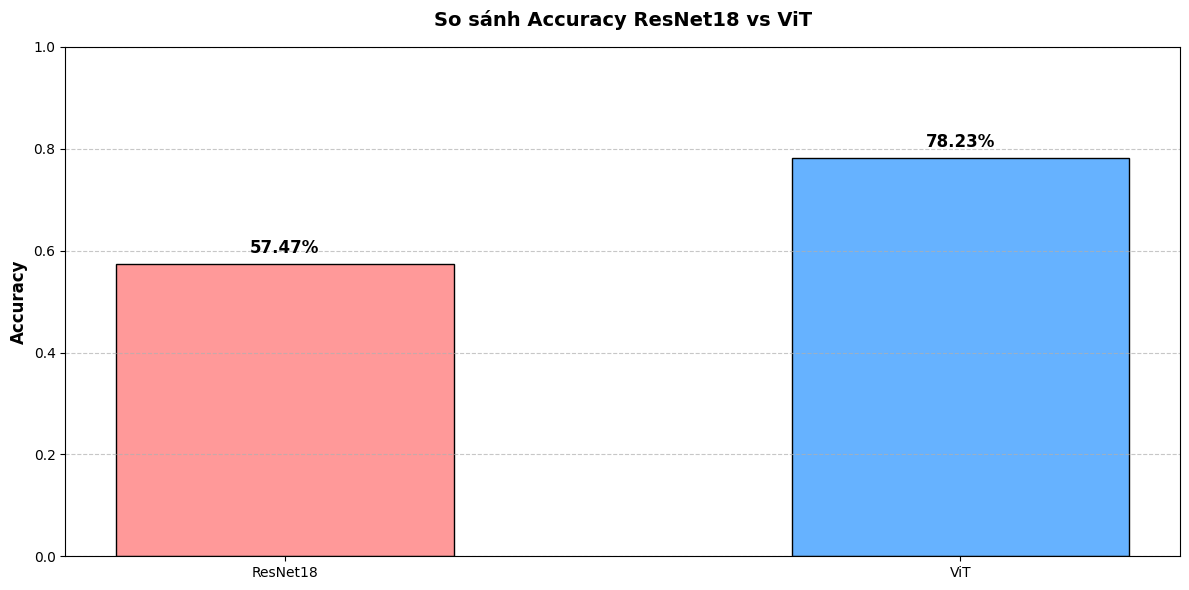

In [5]:
output_dir = '../results/ph07_model_comparison'
os.makedirs(output_dir, exist_ok=True)

models = ['ResNet18', 'ViT']
accuracies = [resnet_final_acc, vit_acc] 

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(models, accuracies, color=['#FF9999', '#66B2FF'], edgecolor='black', width=0.5)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('So sánh Accuracy ResNet18 vs ViT', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height*100:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

save_path_acc = os.path.join(output_dir, 'accuracy_comparison.png')
plt.savefig(save_path_acc, dpi=300, bbox_inches='tight')
print(f"Đã xuất ảnh và lưu tại: {save_path_acc}")

plt.show()

In [6]:
output_dir = '../results/ph07_model_comparison'
os.makedirs(output_dir, exist_ok=True)

classes = ['bcc', 'mel', 'misc', 'nevus', 'sk']
x = np.arange(len(classes))
width = 0.35  

resnet_p  = [0.26, 0.46, 0.47, 0.84, 0.27]
resnet_r  = [0.75, 0.57, 0.68, 0.58, 0.21]
resnet_f1 = [0.39, 0.51, 0.56, 0.68, 0.24]

resnet_report_path = '../results/ph05_resnet_transfer_outputs/classification_report_resnet18_derm7pt.txt'
if os.path.exists(resnet_report_path):
    with open(resnet_report_path, 'r') as f:
        report_text = f.read()
    import re
    p_list, r_list, f1_list = [], [], []
    for cls in classes:
        match = re.search(fr'{cls}\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)', report_text)
        if match:
            p_list.append(float(match.group(1)))
            r_list.append(float(match.group(2)))
            f1_list.append(float(match.group(3)))
    if len(p_list) == len(classes):
        resnet_p, resnet_r, resnet_f1 = p_list, r_list, f1_list

vit_p  = [0.82, 0.73, 0.63, 0.85, 0.57]
vit_r  = [0.56, 0.73, 0.60, 0.87, 0.63]
vit_f1 = [0.67, 0.73, 0.62, 0.86, 0.60]

metrics = [
    (resnet_p, vit_p, 'Precision', 'precision_comparison.png'),
    (resnet_r, vit_r, 'Recall', 'recall_comparison.png'),
    (resnet_f1, vit_f1, 'F1-Score', 'f1_score_comparison.png')
]

data = {
    'Class': classes,
    'Precision (ResNet18)': resnet_p,
    'Precision (ViT)': vit_p,
    'Recall (ResNet18)': resnet_r,
    'Recall (ViT)': vit_r,
    'F1-Score (ResNet18)': resnet_f1,
    'F1-Score (ViT)': vit_f1
}

df_comparison = pd.DataFrame(data)
df_comparison.set_index('Class', inplace=True)

csv_filename = 'metrics_comparison_summary.csv'
save_path_csv = os.path.join(output_dir, csv_filename)

df_comparison.to_csv(save_path_csv, index=True, float_format='%.2f')

display(df_comparison)

,Precision (ResNet18),Precision (ViT),Recall (ResNet18),Recall (ViT),F1-Score (ResNet18),F1-Score (ViT)
Class,,,,,,
bcc,0.2609,0.82,0.7500,0.56,0.3871,0.67
mel,0.4567,0.73,0.5743,0.73,0.5088,0.73
misc,0.4737,0.63,0.6750,0.60,0.5567,0.62
nevus,0.8400,0.85,0.5753,0.87,0.6829,0.86
sk,0.2667,0.57,0.2105,0.63,0.2353,0.60


Đã xuất ảnh Precision và lưu tại: ../results/ph07_model_comparison\precision_comparison.png


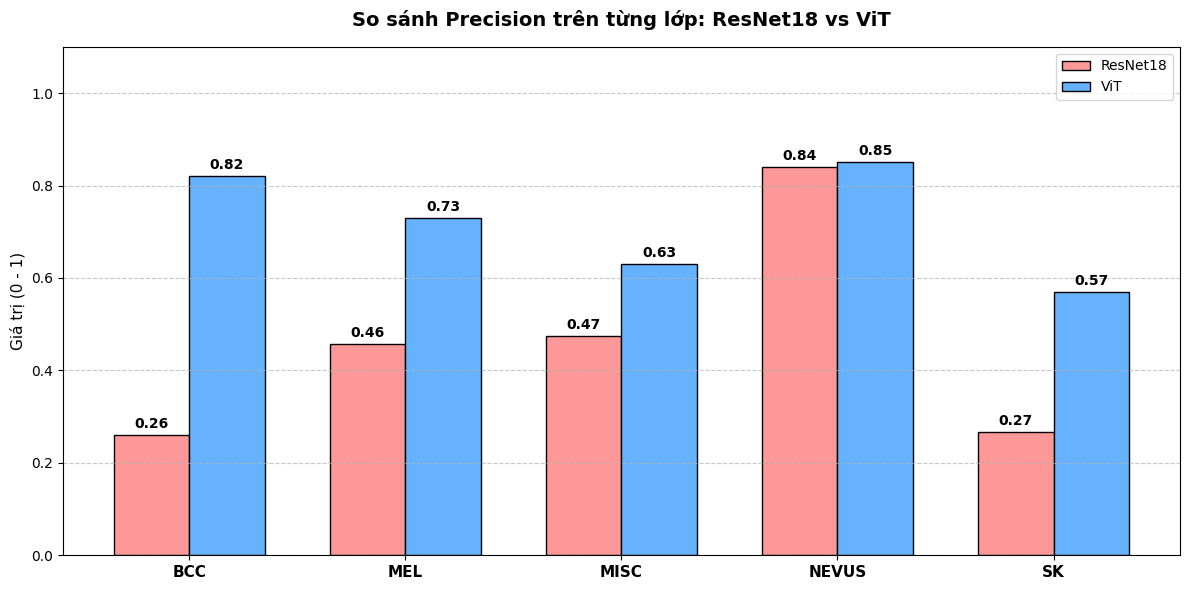

Đã xuất ảnh Recall và lưu tại: ../results/ph07_model_comparison\recall_comparison.png


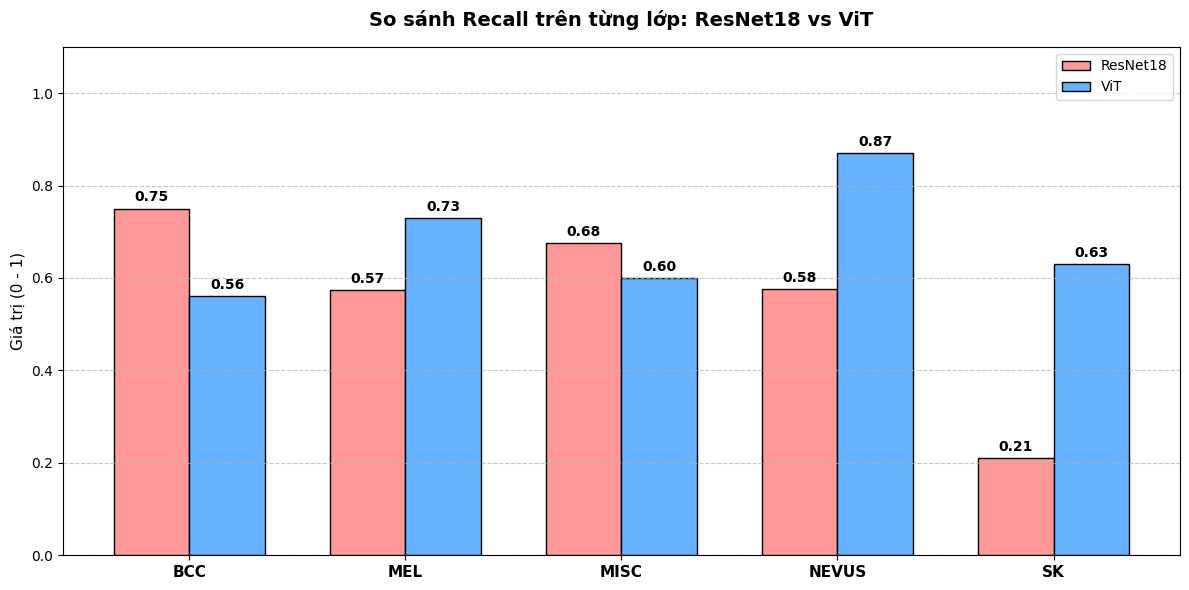

Đã xuất ảnh F1-Score và lưu tại: ../results/ph07_model_comparison\f1_score_comparison.png


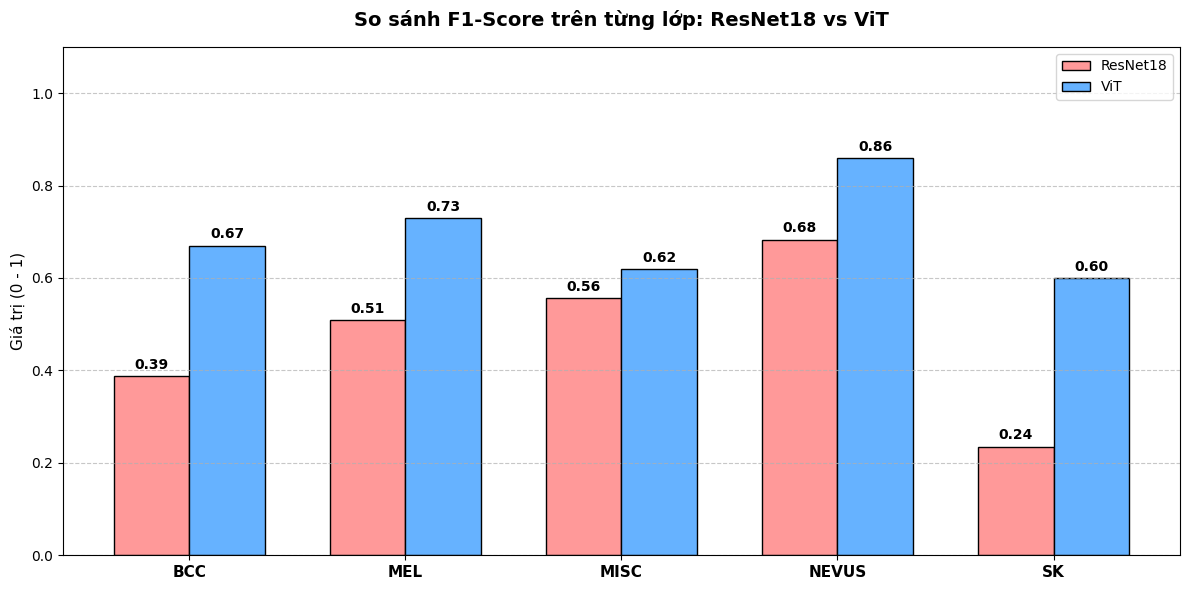

In [7]:
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

for res_data, vit_data, title, filename in metrics:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    rects1 = ax.bar(x - width/2, res_data, width, label='ResNet18', color='#FF9999', edgecolor='black')
    rects2 = ax.bar(x + width/2, vit_data, width, label='ViT', color='#66B2FF', edgecolor='black')
    
    ax.set_ylabel('Giá trị (0 - 1)', fontsize=11)
    ax.set_title(f'So sánh {title} trên từng lớp: ResNet18 vs ViT', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([c.upper() for c in classes], fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    autolabel(rects1, ax)
    autolabel(rects2, ax)
    
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Đã xuất ảnh {title} và lưu tại: {save_path}")
    
    plt.show()

## Tổng kết: Ưu và Nhược điểm của ResNet18 và ViT

### Mô hình ResNet18 (Convolutional Neural Network)

**Ưu điểm:**
* **Kiến trúc nhẹ, tối ưu tài nguyên:** ResNet18 có cấu trúc ít tham số, tiêu tốn ít bộ nhớ GPU và có tốc độ huấn luyện cũng như suy luận rất nhanh. Rất phù hợp để triển khai trên các thiết bị có tài nguyên hạn chế.
* **Trích xuất đặc trưng cục bộ mạnh mẽ:** Cơ chế Convolution giúp mạng lưới cực kỳ nhạy bén với các chi tiết vi mô như kết cấu da, đường viền, điểm màu và hình dạng cục bộ của vết thương.
* **Tích hợp sẵn Inductive Bias:** Nhờ tính translation invariance, ResNet18 có khả năng hội tụ nhanh chóng ngay cả khi tập dữ liệu huấn luyện không quá lớn.

**Nhược điểm:**
* **Góc nhìn hạn hẹp (Thiếu Global Context):** Do kích thước Receptive Field của các filter bị giới hạn, mô hình gặp khó khăn trong việc thiết lập mối liên hệ giữa các vùng da xa nhau trong cùng một bức ảnh.
* **Nhạy cảm với dữ liệu mất cân bằng:** ResNet18 bộc lộ điểm yếu lớn khi dự đoán các lớp thiểu số như Dày sừng tiết bã (`sk`), với chỉ số Precision và Recall rất thấp (chỉ đạt 0.27 và 0.21).
* **Hiệu suất trung bình trên các bệnh nguy hiểm:** Mặc dù Recall của lớp Ung thư hắc tố (Melanoma - `mel`) đã được cải thiện (0.57), nhưng F1-score vẫn chỉ ở mức 0.51, cho thấy mô hình vẫn còn nhầm lẫn và thiếu độ tin cậy tuyệt đối trong chẩn đoán y khoa đối với lớp ác tính.

---

### Mô hình Vision Transformer (ViT)

**Ưu điểm:**
* **Cơ chế Self-Attention toàn cục:** Thay vì quét từng vùng nhỏ, ViT chia ảnh thành các patches và tính toán mức độ chú ý giữa tất cả các mảnh ngay từ những lớp đầu tiên. Khả năng nhìn nhận bối cảnh tổng thể (mối quan hệ giữa vùng tổn thương và da lành xung quanh) giúp ViT vượt trội trong phân tích ảnh y tế.
* **Xử lý xuất sắc sự mất cân bằng dữ liệu:** Không bị phụ thuộc quá mức vào lớp đa số (`nevus`), ViT nâng cao và duy trì độ ổn định F1-Score ở cả những lớp thiếu hụt dữ liệu trầm trọng như `sk` (0.60) và `bcc` (0.67), vượt trội hơn hẳn ResNet.
* **Độ tin cậy y khoa vượt bậc:** ViT giải quyết được bài toán khó nhất là lớp ung thư ác tính (`mel`) khi nâng cả Precision và Recall lên mức 0.73. Điều này đồng nghĩa với việc mô hình vừa giảm thiểu tỷ lệ chẩn đoán sai, vừa tránh bỏ lọt bệnh nhân.

**Nhược điểm:**
* **Chi phí tính toán và tài nguyên lớn:** Quá trình tính toán ma trận Self-Attention rất phức tạp do tăng theo bình phương số lượng patch, đòi hỏi cấu hình phần cứng mạnh, tốn nhiều VRAM và thời gian huấn luyện lâu hơn hẳn ResNet18.
* **Phụ thuộc mạnh vào Transfer Learning:** Do không có sẵn các giả định quy nạp tự nhiên như CNN, ViT cần một lượng dữ liệu khổng lồ để tự học các quy luật thị giác. Nếu không có bước Pre-train/Fine-tune trên tập lớn như ImageNet hay HAM10000, ViT gần như không thể hội tụ và hoạt động tốt nếu chỉ train từ đầu trên một tập dữ liệu nhỏ như Derm7pt.